# Phase 1.1 - Setup Colab + organisation du dataset
Objectif : configurer l'environnement Colab, telecharger le dataset via l'API Kaggle, organiser les dossiers en train/val par classe, et afficher quelques images pour verifier.

## Configuration du projet

In [ ]:
import os

DATA_ROOT = "./data"
RAW_ROOT = DATA_ROOT
train_root = os.path.join(RAW_ROOT, "train")

TARGET_CLASSES = ["apple", "banana"]
if not os.path.isdir(train_root):
    CLASSES = []
else:
    missing = [c for c in TARGET_CLASSES if not os.path.isdir(os.path.join(train_root, c))]
    if missing:
        raise FileNotFoundError(f"Classes introuvables dans train/: {missing}")
    CLASSES = TARGET_CLASSES

## Setup de l'API Kaggle (local)
Telechargez kaggle.json depuis Kaggle (Account -> API -> Create New Token) et placez-le dans votre dossier utilisateur ou dans ~/.kaggle/.

In [151]:
!pip install kaggle -q

import os
import shutil

kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_json = os.path.join(kaggle_dir, "kaggle.json")
alt_kaggle_json = os.path.expanduser("~/kaggle.json")

os.makedirs(kaggle_dir, exist_ok=True)
if os.path.isfile(alt_kaggle_json) and not os.path.isfile(kaggle_json):
    shutil.copy(alt_kaggle_json, kaggle_json)
if not os.path.isfile(kaggle_json):
    raise FileNotFoundError(
        "kaggle.json introuvable. Telechargez-le depuis Kaggle (Account -> API -> Create New Token) "
        "et placez-le dans ~/.kaggle/ ou ~/"
    )
os.chmod(kaggle_json, 0o600)

DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
import os
import zipfile

os.makedirs(DATA_ROOT, exist_ok=True)
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition -p "$DATA_ROOT"

zip_path = os.path.join(DATA_ROOT, "fruit-and-vegetable-image-recognition.zip")
extract_dir = DATA_ROOT
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
fruit-and-vegetable-image-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


## Organisation des dossiers (train/val par classe)

In [ ]:
import os
import shutil
import random
from glob import glob

def list_images(path):
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    files = []
    for pattern in patterns:
        files.extend(glob(os.path.join(path, pattern)))
    return files

files_by_class = {cls: list_images(os.path.join(RAW_ROOT, "train", cls)) for cls in CLASSES}
OUTPUT_ROOT = os.path.join(DATA_ROOT, "split")

# Rebuild split to keep only selected classes
shutil.rmtree(OUTPUT_ROOT, ignore_errors=True)
for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(OUTPUT_ROOT, split, cls), exist_ok=True)

random.seed(42)
splits = {}
for cls, files in files_by_class.items():
    random.shuffle(files)
    split_idx = int(0.8 * len(files))
    splits[cls] = {"train": files[:split_idx], "val": files[split_idx:]}

for cls in CLASSES:
    for src in splits[cls]["train"]:
        shutil.copy(src, os.path.join(OUTPUT_ROOT, "train", cls))
    for src in splits[cls]["val"]:
        shutil.copy(src, os.path.join(OUTPUT_ROOT, "val", cls))

for split in ["train", "val"]:
    for cls in CLASSES:
        path = os.path.join(OUTPUT_ROOT, split, cls)
        print(f"{path} : {len(os.listdir(path))} images")

./data\split\train\apple : 54 images
./data\split\train\banana : 60 images
./data\split\train\beetroot : 70 images
./data\split\train\bell pepper : 72 images
./data\split\train\cabbage : 73 images
./data\split\train\capsicum : 71 images
./data\split\train\carrot : 65 images
./data\split\train\cauliflower : 63 images
./data\split\train\chilli pepper : 69 images
./data\split\train\corn : 69 images
./data\split\train\cucumber : 75 images
./data\split\train\eggplant : 67 images
./data\split\train\garlic : 73 images
./data\split\train\ginger : 54 images
./data\split\train\grapes : 80 images
./data\split\train\jalepeno : 70 images
./data\split\train\kiwi : 70 images
./data\split\train\lemon : 65 images
./data\split\train\lettuce : 77 images
./data\split\train\mango : 68 images
./data\split\train\onion : 75 images
./data\split\train\orange : 55 images
./data\split\train\paprika : 66 images
./data\split\train\pear : 71 images
./data\split\train\peas : 80 images
./data\split\train\pineapple : 7

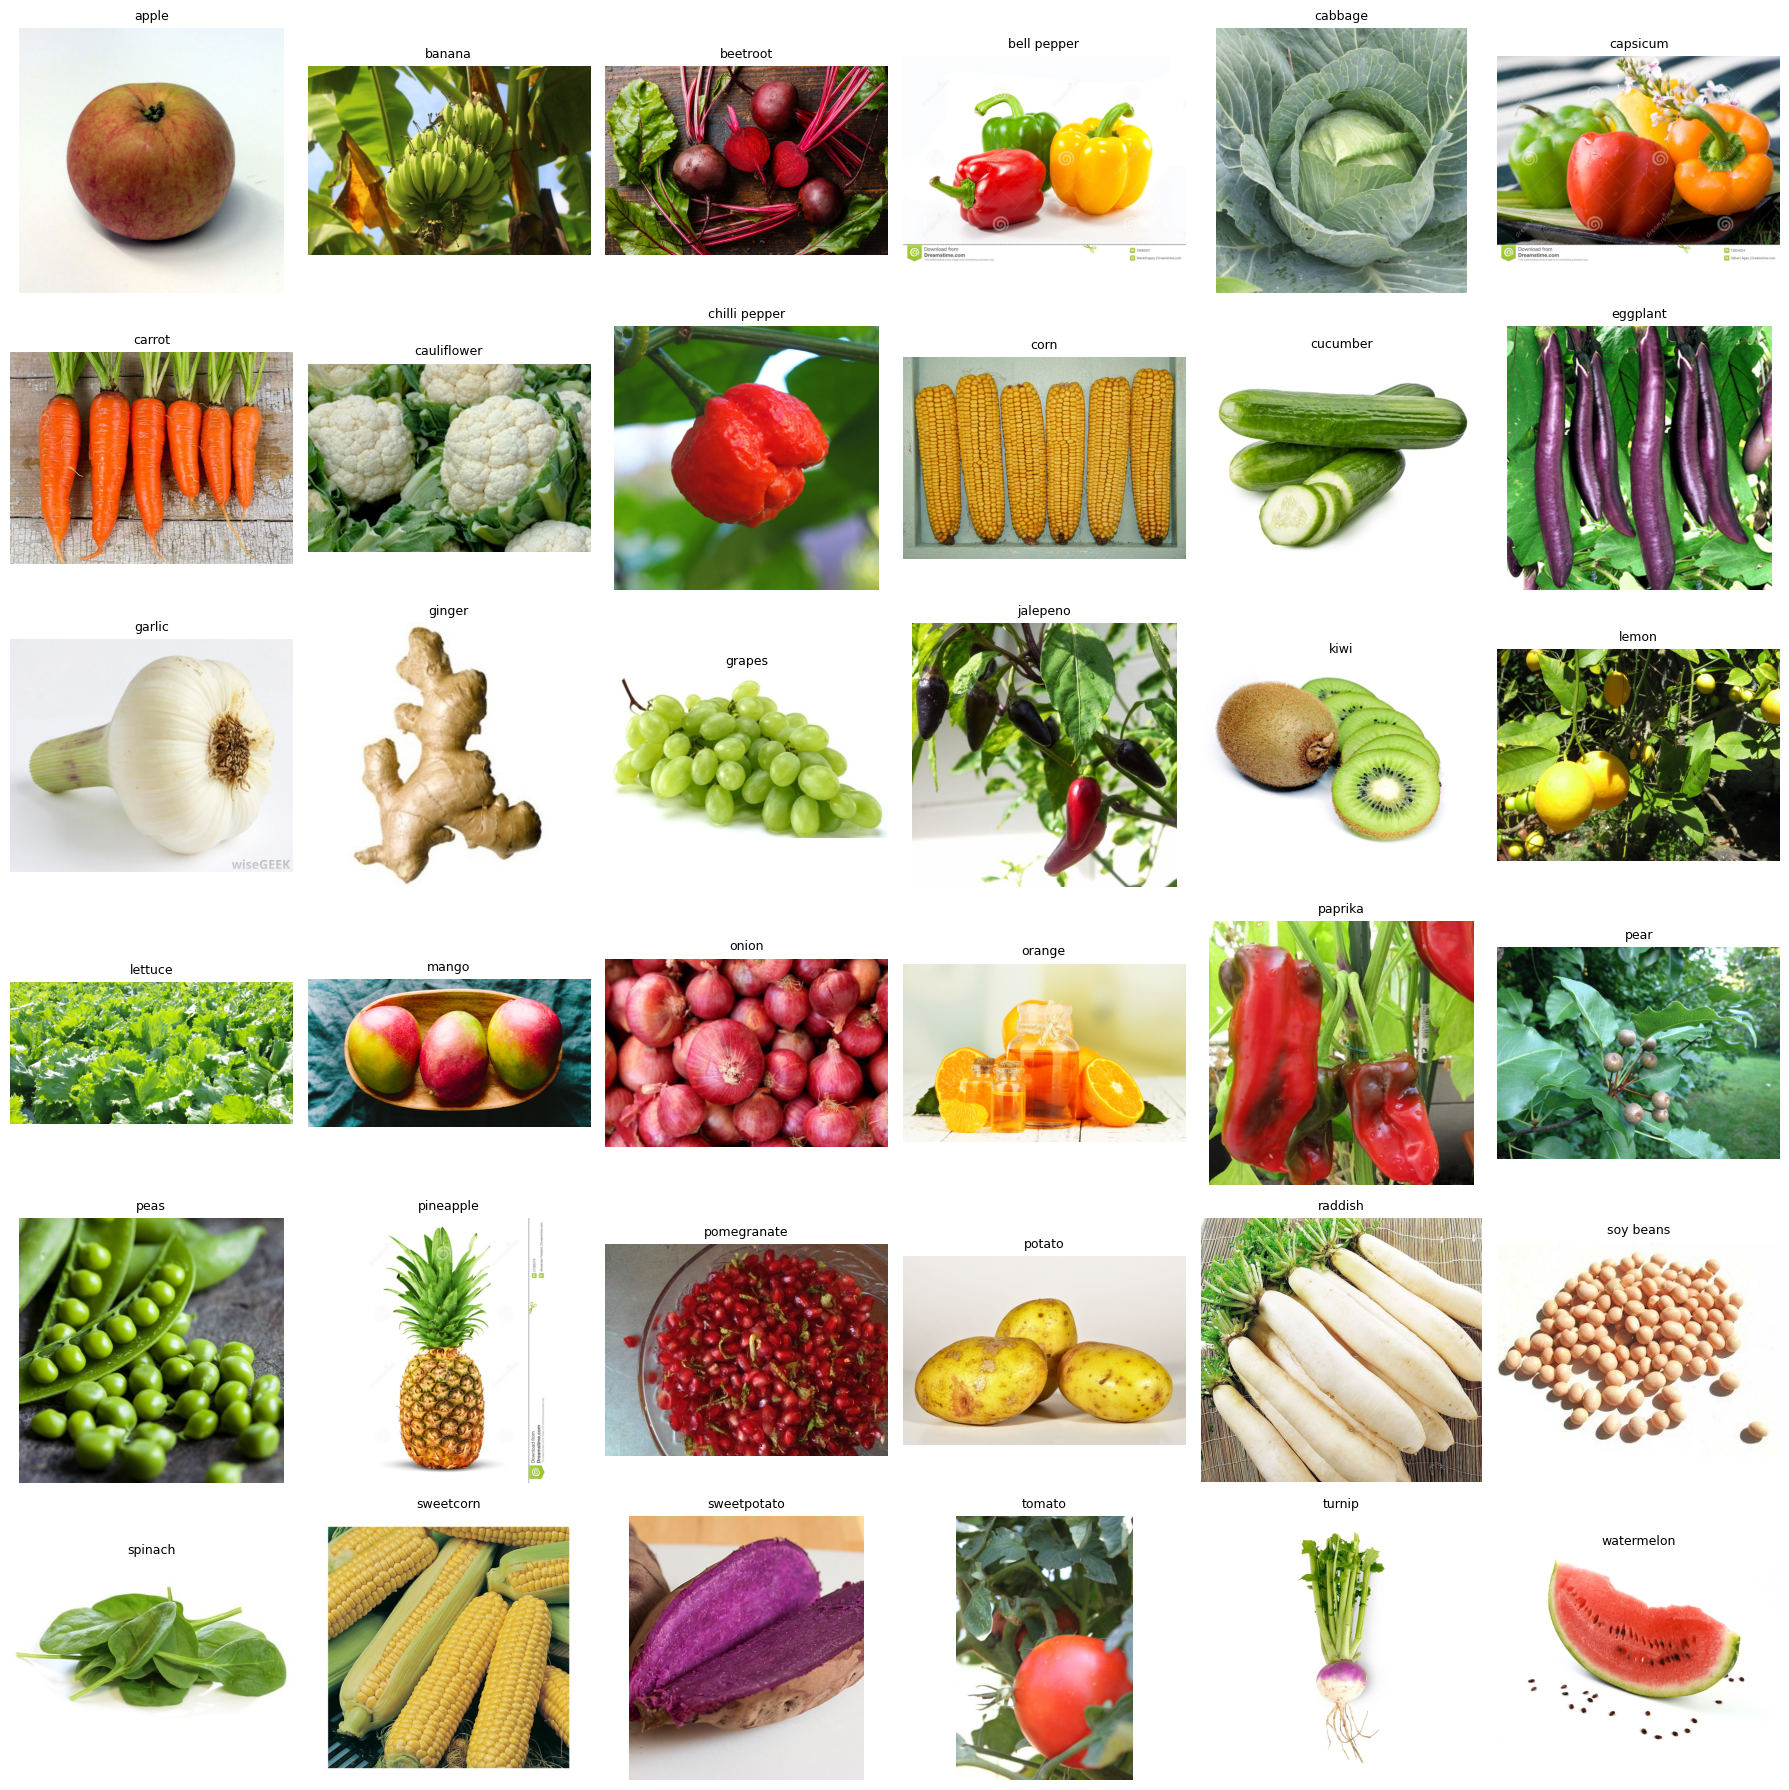

Classes affichees: 36


In [154]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math

samples = []
for cls in CLASSES:
    files = files_by_class.get(cls, [])
    if files:
        samples.append((cls, random.choice(files)))

num_samples = len(samples)
if num_samples == 0:
    print("Aucune image trouvee. Verifiez que le dataset est bien extrait et que CLASSES n'est pas vide.")
else:
    cols = 6
    rows = math.ceil(num_samples / cols)
    fig = plt.figure(figsize=(3 * cols, 3 * rows))

    for i, (cls, path) in enumerate(samples):
        img = mpimg.imread(path)
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(cls, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Classes affichees: {num_samples}")

In [156]:
# Phase 1.2 - Preprocessing : normalisation + batching
import tensorflow as tf

# Paramètres
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Utiliser le split (contenant uniquement apple/banana)
PIPELINE_ROOT = os.path.join(DATA_ROOT, "split")
train_dir = os.path.join(PIPELINE_ROOT, "train")
val_dir = os.path.join(PIPELINE_ROOT, "val")

print("Pipeline root:", PIPELINE_ROOT)
print("Train dir:", train_dir)
print("Val dir:", val_dir)

# Verifier l'existence des dossiers
if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
    raise FileNotFoundError("Dossiers de train/val introuvables. Exécutez l'étape de split d'abord.")

# Chargement des datasets depuis les dossiers
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Classes detectees (train):", CLASS_NAMES)
if set(CLASS_NAMES) != set(CLASSES):
    raise ValueError(f"Classes inattendues dans le split: {CLASS_NAMES}")

# Normalisation
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255.0)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

# Cache + prefetch
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Afficher le premier batch
images, labels = next(iter(train_ds))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype, "min:", float(tf.reduce_min(images)), "max:", float(tf.reduce_max(images)))
print("Unique labels in batch:", tf.unique(labels).y.numpy())


Pipeline root: ./data\split
Train dir: ./data\split\train
Val dir: ./data\split\val
Found 2478 files belonging to 36 classes.
Found 637 files belonging to 36 classes.
Classes detectees (train): ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Images shape: (32, 128, 128, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'> min: 0.0 max: 1.0
Unique labels in batch: [ 6  4 26 18 31 23 13 11 28 16 19 25 34 27 10  2 30 24 22 17 29  8 14  9]


In [157]:
# Sanity check: class counts and label mapping
import os
from collections import Counter

def count_images_per_class(root_dir, classes):
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if os.path.isdir(cls_dir):
            counts[cls] = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            counts[cls] = 0
    return counts

class_names = CLASS_NAMES if 'CLASS_NAMES' in globals() else CLASSES
train_counts = count_images_per_class(train_dir, class_names)
val_counts = count_images_per_class(val_dir, class_names)

print("Train classes:", len(train_counts))
print("Val classes:", len(val_counts))
print("Train min/median/max:", min(train_counts.values()), sorted(train_counts.values())[len(train_counts)//2], max(train_counts.values()))
print("Val min/median/max:", min(val_counts.values()), sorted(val_counts.values())[len(val_counts)//2], max(val_counts.values()))

# Spot-check a small label batch distribution
label_counter = Counter()
for _, y in train_ds.take(5):
    label_counter.update(y.numpy().tolist())
print("Sample label distribution (5 batches):", dict(label_counter))

Train classes: 36
Val classes: 36
Train min/median/max: 54 70 80
Val min/median/max: 14 18 20
Sample label distribution (5 batches): {20: 7, 1: 4, 11: 5, 10: 5, 35: 4, 22: 2, 18: 4, 2: 5, 30: 6, 34: 5, 27: 3, 9: 10, 0: 3, 25: 8, 26: 3, 33: 5, 16: 3, 6: 7, 13: 7, 8: 3, 3: 10, 19: 7, 28: 6, 17: 2, 7: 5, 15: 2, 23: 8, 12: 2, 5: 3, 21: 2, 29: 1, 14: 5, 31: 2, 32: 2, 4: 4}


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Phase 1.3 - Architecture CNN from scratch
# Build a simple CNN to inspect shapes and parameter counts

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
    ],
    name="data_augmentation",
)

def build_cnn_scratch(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(data_augmentation)

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.1))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.15))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Final layer: binary vs multi-class
    if num_classes == 2:
        model.add(layers.Dense(1, activation='sigmoid'))
    else:
        model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Enforce two-class setup globally
CLASS_NAMES = CLASSES
num_classes = len(CLASS_NAMES)
if num_classes != 2:
    raise ValueError(f"Attendu 2 classes (apple/banana), trouve: {CLASS_NAMES}")

# Calculate expected shapes given IMG_SIZE
H, W = IMG_SIZE
h1, w1 = H // 2, W // 2
h2, w2 = h1 // 2, w1 // 2
h3, w3 = h2 // 2, w2 // 2
expected_flatten = h3 * w3 * 128

print(f"IMG_SIZE: {IMG_SIZE}")
print(f"Num classes: {num_classes}")
print(f"After Block1 (H/2,W/2,32): ({h1},{w1},32)")
print(f"After Block2 (H/4,W/4,64): ({h2},{w2},64)")
print(f"After Block3 (H/8,W/8,128): ({h3},{w3},128)")
print(f"Expected Flatten units: {expected_flatten}")

# Build, summarize and compile
model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=num_classes)
model_scratch.summary()

# Choose appropriate loss
if num_classes == 2:
    loss = 'binary_crossentropy'
else:
    loss = 'sparse_categorical_crossentropy'

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model_scratch.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


IMG_SIZE: (128, 128)
Num classes: 36
After Block1 (H/2,W/2,32): (64,64,32)
After Block2 (H/4,W/4,64): (32,32,64)
After Block3 (H/8,W/8,128): (16,16,128)
Expected Flatten units: 32768


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,491,364 (32.39 MB)

 Trainable params: 8,491,364 (32.39 MB)

 Non-trainable params: 0 (0.00 B)

In [159]:
# Phase 1.4 - Entrainement et diagnostic overfitting
import datetime, time
import tensorflow as tf
import matplotlib.pyplot as plt

# Callbacks
log_dir = "logs/scratch/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# Entrainement
start = time.time()
history_scratch = model_scratch.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)
training_time_scratch = time.time() - start
print(f"Temps d'entrainement : {training_time_scratch:.0f}s")
print(f"val_accuracy finale : {max(history_scratch.history['val_accuracy']):.3f}")

# Estimer l'epoch ou la val_loss commence a remonter
val_losses = history_scratch.history.get('val_loss', [])
overfit_epoch = None
for i in range(1, len(val_losses)):
    if val_losses[i] > val_losses[i - 1]:
        overfit_epoch = i + 1
        break
if overfit_epoch is not None:
    print(f"Point de divergence (val_loss remonte) vers epoch {overfit_epoch}")
else:
    print("Pas de remontee claire de la val_loss sur ces epochs.")

# Lancer TensorBoard (si supporte dans l'environnement)
try:
    get_ipython().run_line_magic('load_ext', 'tensorboard')
    get_ipython().run_line_magic('tensorboard', f'--logdir {os.path.dirname(log_dir)}')
except Exception:
    print("TensorBoard magic non disponible dans cet environnement. Ouvrez TensorBoard manuellement en pointant --logdir logs/scratch")

# Utilitaire de trace
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['loss'], label='Train loss')
    ax1.plot(history.history['val_loss'], label='Val loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax2.plot(history.history['accuracy'], label='Train accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f"curves_{title.lower().replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history(history_scratch, "CNN scratch")


Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.0363 - loss: 3.5961 - val_accuracy: 0.0722 - val_loss: 3.5356 - learning_rate: 1.0000e-04
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.0702 - loss: 3.4250 - val_accuracy: 0.1130 - val_loss: 3.2844 - learning_rate: 1.0000e-04
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.1049 - loss: 3.2115 - val_accuracy: 0.1633 - val_loss: 3.0335 - learning_rate: 1.0000e-04
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.1594 - loss: 3.0062 - val_accuracy: 0.1915 - val_loss: 2.8801 - learning_rate: 1.0000e-04
Epoch 5/20
 1/78 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.1875 - loss: 2.9843

KeyboardInterrupt: 

## Verifications
Ratio 80/20 respecte, grille 2x3 affichee, shapes finissent par 3 (RGB) ou 1 (gris).
Si erreur kaggle.json, verifier les permissions avec chmod 600 ~/.kaggle/kaggle.json.